# Netflix Content Catalog: Deep Dive Exploratory Analysis
**Author:** Mark Mutinda  
**Date:** Jan 2026  

### Objective
This project aims to analyze the Netflix dataset to understand the platform's content strategy. We will explore the growth of the library over time, regional content distribution, and the balance between Movies and TV Shows. 

### Dataset Overview
The dataset contains information on nearly 9,000 titles, including metadata such as director, cast, country, and release year.

## Initializing the Analytical Environment
We begin by importing **Pandas** for data manipulation and **Seaborn/Matplotlib** for visualization. These tools allow us to transform raw CSV data into actionable insights.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# We are creating a variable called 'df' (short for DataFrame)
df = pd.read_csv('netflix_titles.csv')

# Verify it worked
# This displays the first 5 rows of the data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Integrity Check
Before analyzing, we must understand the "cleanliness" of our data. We are looking for missing values that could skew our results and verifying that numerical columns are stored correctly.

In [2]:
# Check the shape of the data (Rows, Columns)
print(f"Dataset Shape: {df.shape}")

# Check for missing values in each column
missing_data = df.isnull().sum()
print("\nMissing values per column:")
print(missing_data[missing_data > 0])

# Check data types
print("\nColumn Data Types:")
print(df.dtypes)

Dataset Shape: (8807, 12)

Missing values per column:
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64

Column Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


 **Observation:** We noticed significant gaps in the `director` and `country` columns. Since we cannot "guess" these values, we will flag them as 'Unknown' to maintain the integrity of the rows.

## Data Remediation Strategy
To ensure a robust analysis, we perform three specific actions:
1. **Categorical Imputation:** Filling 'Unknown' for Director, Cast, and Country.
2. **Row Removal:** Dropping rows with missing 'date_added' as they are critical for trend analysis.
3. **Type Casting:** Converting date strings into Python Datetime objects.

In [3]:
# Fill large missing blocks with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop the tiny amount of rows with missing date_added or rating
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Final check: verify there are zero nulls left
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [4]:
# Convert 'date_added' to a proper datetime format
# We use strip() to remove any accidental leading/trailing spaces
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Extract the year and create a new column
df['year_added'] = df['date_added'].dt.year.astype(int)

# View the new column alongside the title
print(df[['title', 'date_added', 'year_added']].head())

                   title date_added  year_added
0   Dick Johnson Is Dead 2021-09-25        2021
1          Blood & Water 2021-09-24        2021
2              Ganglands 2021-09-24        2021
3  Jailbirds New Orleans 2021-09-24        2021
4           Kota Factory 2021-09-24        2021


## Analysis: The Content War (Movies vs. TV Shows)
The first question any analyst asks is: "What does Netflix actually sell?" We will visualize the split between feature films and episodic content.

C:\Users\user\AppData\Local\Temp\ipykernel_3468\3326703339.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Reds_r')


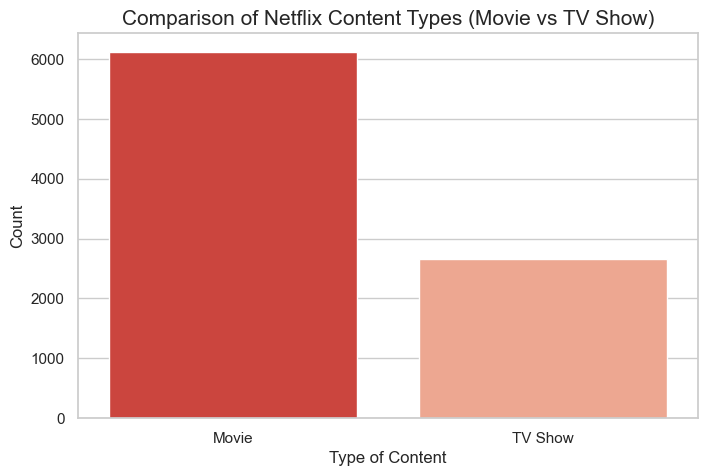

In [5]:
# Visual style setting
sns.set_theme(style="whitegrid")

# Create a Count Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='type', data=df, palette='Reds_r')

# Add titles and labels
plt.title('Comparison of Netflix Content Types (Movie vs TV Show)', fontsize=15)
plt.xlabel('Type of Content', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

> **Observation:** Movies dominate the platform, outnumbering TV shows by nearly 2:1. However, the line graphs below will reveal if this gap is narrowing.

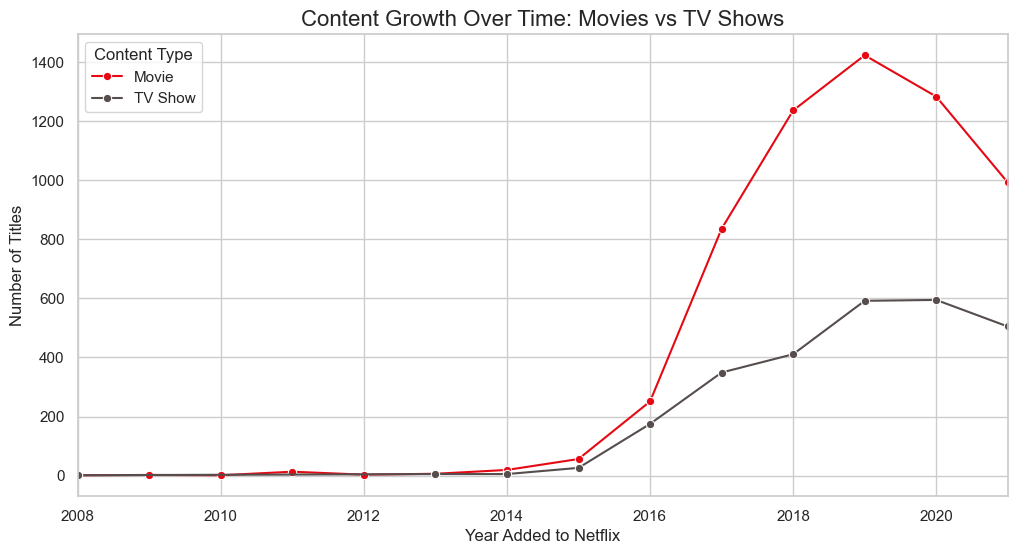

In [6]:
# Group data by year and type
content_by_year = df.groupby(['year_added', 'type']).size().reset_index(name='count')

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=content_by_year, x='year_added', y='count', hue='type', marker='o', palette=['#E50914', '#564d4d'])

# Aesthetics
plt.title('Content Growth Over Time: Movies vs TV Shows', fontsize=16)
plt.xlabel('Year Added to Netflix', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(title='Content Type')
plt.xlim(2008, 2021) # Focusing on the modern era of streaming
plt.show()

## Regional Content Distribution
Netflix is a global platform. In this section, we analyze which countries contribute most to the catalog to identify where Netflix is focusing its production and licensing resources.

C:\Users\user\AppData\Local\Temp\ipykernel_3468\3946081759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


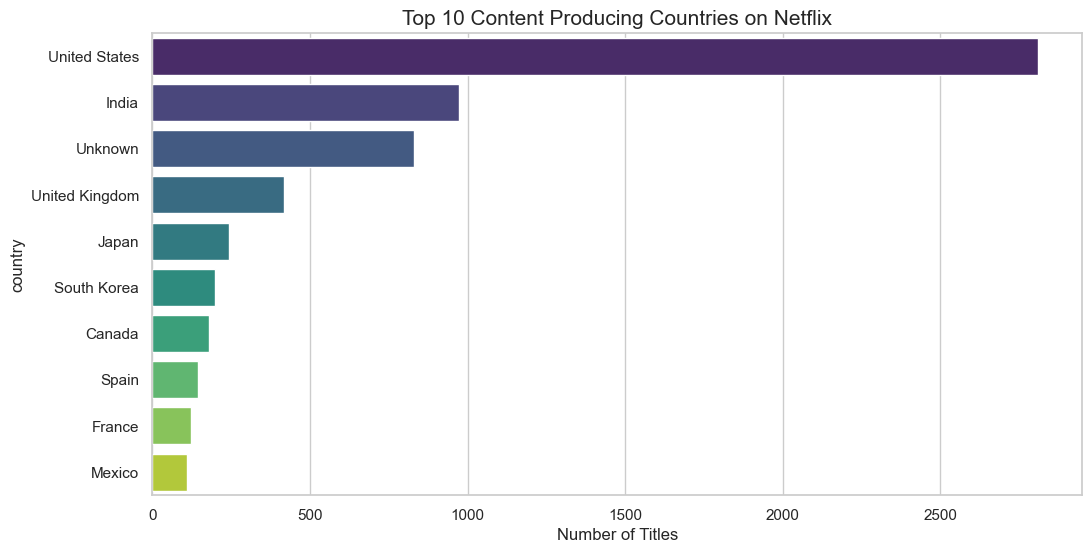

In [16]:
# Top 10 Countries with most content
plt.figure(figsize=(12,6))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')

plt.title('Top 10 Content Producing Countries on Netflix', fontsize=15)
plt.xlabel('Number of Titles')
plt.show()


**Observation:** The **United States** is by far the largest producer of content on the platform, followed by **India** and the **United Kingdom**. This distribution highlights Netflix's heavy investment in the North American market while maintaining a strong foothold in Bollywood and European cinema.

### Genre Analysis (Multivariate Handling)
Netflix titles are often categorized under multiple genres (e.g., 'Documentaries, International Movies'). 
To analyze the true popularity of genres, we "unstack" these comma-separated strings into individual rows. 
This process increases our row count but allows for a granular view of the platform's content diversity.

C:\Users\user\AppData\Local\Temp\ipykernel_3468\4124038154.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='genre', data=genres_df, order=genres_df['genre'].value_counts().index[:15], palette='viridis')


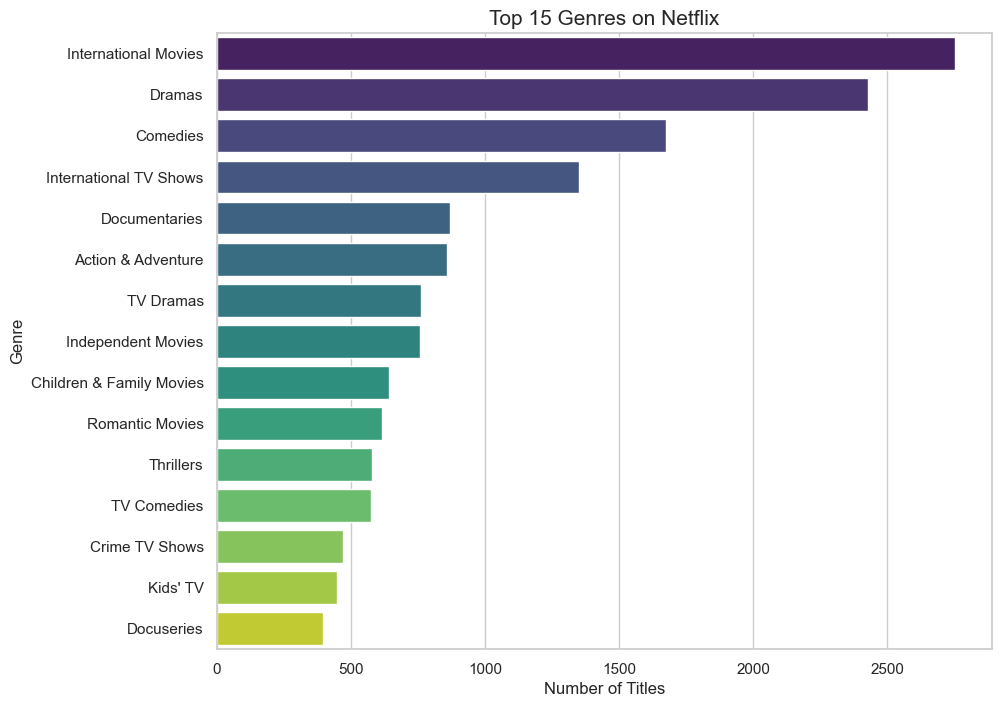

In [9]:
# ANALYZING GENRES: Exhaustive breakdown
# Split, Stack, and Reset Index to avoid the "Duplicate Labels" error
genres_df = df.set_index('title')['listed_in'].str.split(', ', expand=True).stack().reset_index()

# Rename columns for clarity (the stacked column is automatically named '0')
genres_df.columns = ['title', 'level_1', 'genre']

# Plotting the top 15 genres
plt.figure(figsize=(10, 8))
sns.countplot(y='genre', data=genres_df, order=genres_df['genre'].value_counts().index[:15], palette='viridis')

plt.title('Top 15 Genres on Netflix', fontsize=15)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

**Observation:** 'International Movies' and 'Dramas' are the most prevalent genres, suggesting Netflix’s heavy investment in global markets rather than just Hollywood-centric blockbusters.

## Bivariate Analysis: Movie Duration vs. Release Year
We will filter for 'Movies' only and convert the 'duration' string (e.g., '90 min') into an integer to analyze trends in film length over the decades.

Does the modern attention span result in shorter movies? We look at the relationship between the `release_year` and the `duration` (in minutes) to see if cinematic lengths have shifted over the decades.

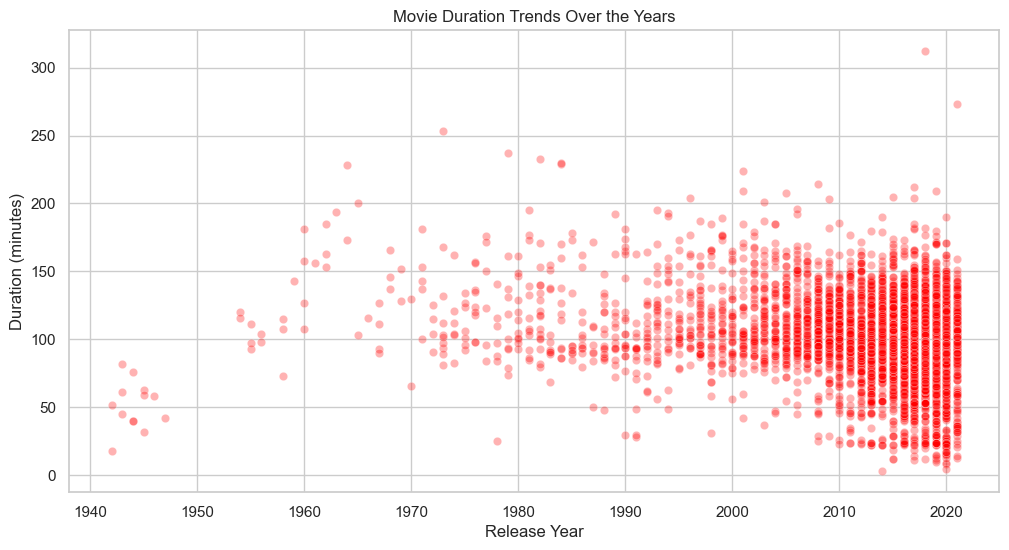

In [10]:
# Filter movies and clean duration column
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=movies, x='release_year', y='duration_min', alpha=0.3, color='red')
plt.title('Movie Duration Trends Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()

**Observation:** While most movies cluster between the 80 to 120-minute mark, there is a visible density increase in the modern era (2000–2021). Interestingly, there are many outliers with very short durations in recent years, which may represent experimental short-form content or documentaries.

## Target Audience: Analyzing Content Ratings
Understanding the maturity rating of content is vital for identifying Netflix's target demographic. By splitting these by content type, we can see if TV shows and Movies follow the same age-rating strategy.

C:\Users\user\AppData\Local\Temp\ipykernel_3468\2395242155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma')


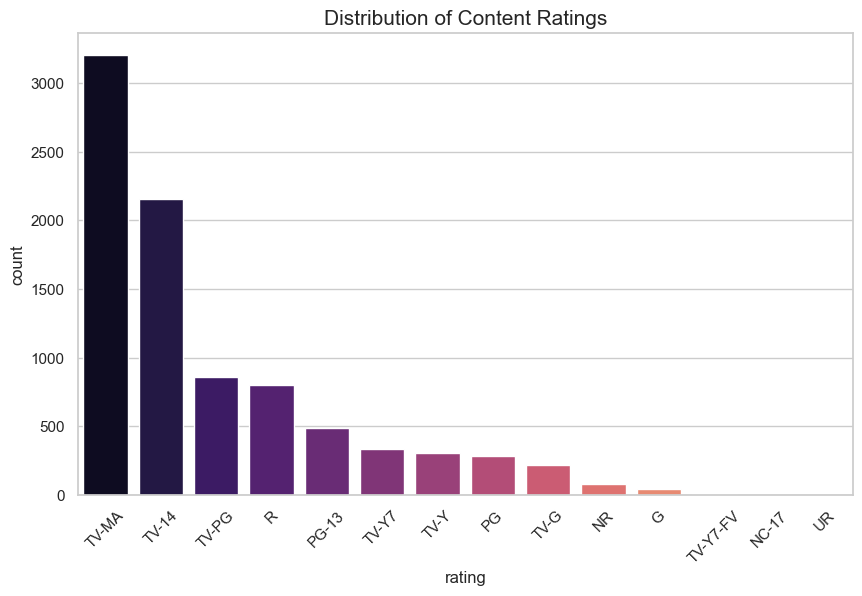

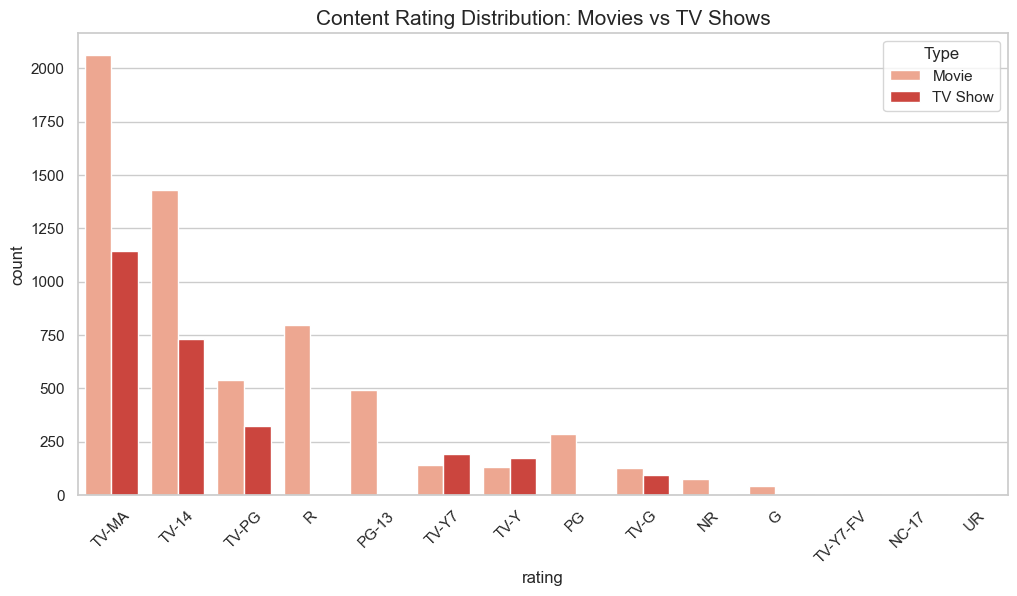

In [15]:
# Rating Distribution (TV-MA, PG-13, etc.)
plt.figure(figsize=(10,6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma')
plt.title('Distribution of Content Ratings', fontsize=15)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index, palette='Reds')
plt.title('Content Rating Distribution: Movies vs TV Shows', fontsize=15)
plt.legend(title='Type', loc='upper right')
plt.xticks(rotation=45)
plt.show()

**Observation:** The majority of Netflix content is rated **TV-MA** (Mature Audiences) and **TV-14**. Interestingly, TV-MA is significantly more prevalent in TV Shows than in Movies, suggesting that Netflix's original series strategy leans heavily toward adult-oriented "prestige" drama to compete with networks like HBO.

## Movie Duration: Descriptive Statistics
Beyond the scatter plot, we need to understand the 'Average' Netflix movie. Is the platform dominated by short indie films or long epics? We use a Boxplot to identify the median and outliers.

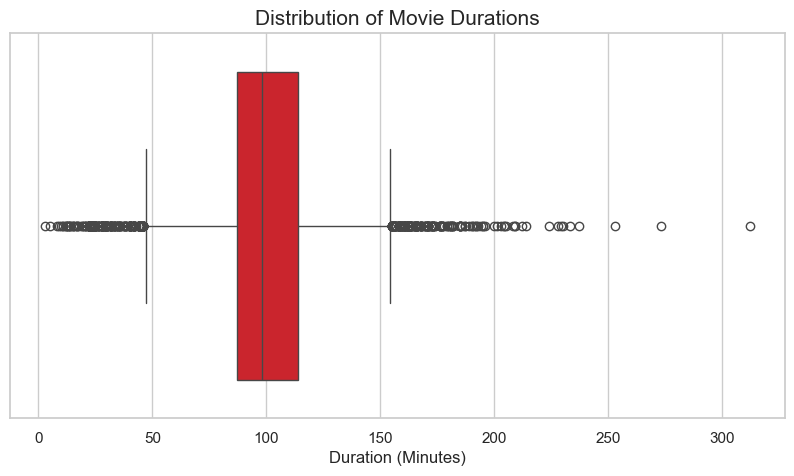

Average Movie Duration: 99.58 minutes
Median Movie Duration: 98.00 minutes


In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=movies['duration_min'], color='#E50914')
plt.title('Distribution of Movie Durations', fontsize=15)
plt.xlabel('Duration (Minutes)')
plt.show()

print(f"Average Movie Duration: {movies['duration_min'].mean():.2f} minutes")
print(f"Median Movie Duration: {movies['duration_min'].median():.2f} minutes")

**Observation:** The median movie length is approximately **98 minutes**. The boxplot reveals several 'outliers'—movies exceeding 200 minutes or shorter than 40 minutes. This suggests a highly standardized content format suited for digital streaming consumption.

## Strategy Shift: New Releases vs. Archive Content
Does Netflix prioritize adding brand-new movies, or is it a repository for older classics? We will create a "Lag" analysis to see the gap between a movie's release and its arrival on the platform.

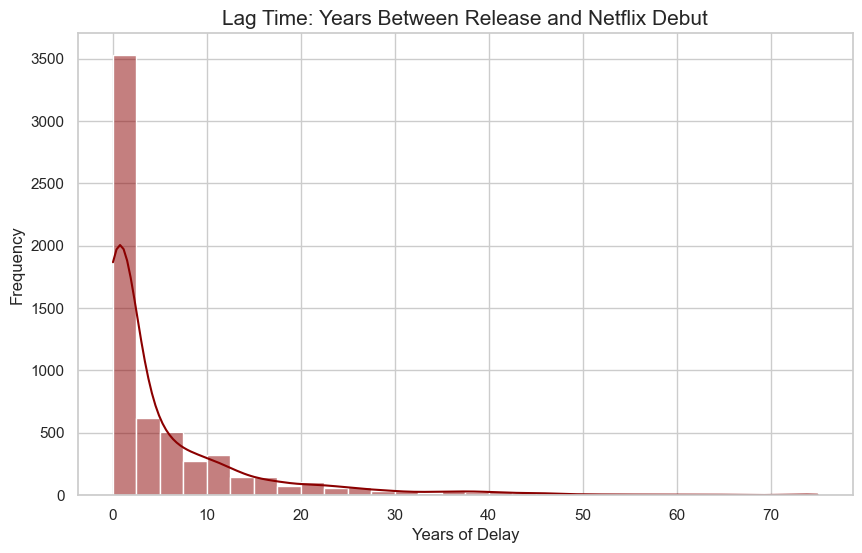

In [13]:
# Create a 'Lag' column
movies['year_diff'] = movies['year_added'] - movies['release_year']

plt.figure(figsize=(10, 6))
sns.histplot(movies[movies['year_diff'] >= 0]['year_diff'], bins=30, kde=True, color='darkred')
plt.title('Lag Time: Years Between Release and Netflix Debut', fontsize=15)
plt.xlabel('Years of Delay')
plt.ylabel('Frequency')
plt.show()

**Observation:** The massive spike at '0' on the X-axis confirms that Netflix has shifted toward a "Day-and-Date" or "Recent Release" model. Most content added in recent years was produced in the same year, highlighting the move away from being a "back-catalog" service.

## The Faces of Netflix: Top 10 Most Frequent Actors
Just as we analyzed genres, we can "unstack" the cast members to see which actors appear most frequently across the entire catalog. This identifies "Netflix's favorite actors"—the stars who likely drive significant viewership for the platform.

C:\Users\user\AppData\Local\Temp\ipykernel_3468\1903412723.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='actor', data=cast_df, order=cast_df['actor'].value_counts().index[:10], palette='rocket')


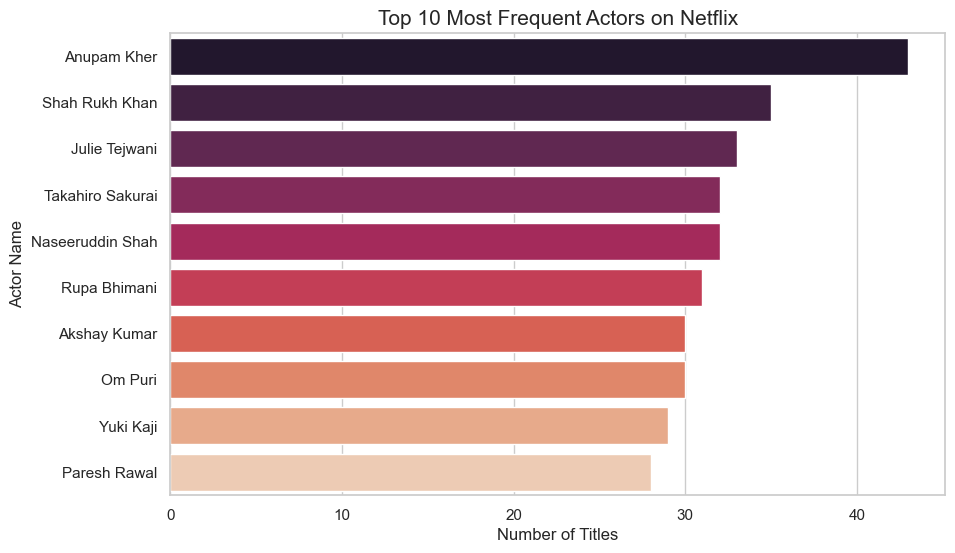

In [18]:
# ANALYZING CAST: Unstacking comma-separated strings
# We drop 'Unknown' values first so they don't dominate the chart
cast_df = df[df['cast'] != 'Unknown'].set_index('title')['cast'].str.split(', ', expand=True).stack().reset_index()

# Rename the stacked column to 'actor'
cast_df.columns = ['title', 'level_1', 'actor']

# Plotting the top 10 actors
plt.figure(figsize=(10, 6))
sns.countplot(y='actor', data=cast_df, order=cast_df['actor'].value_counts().index[:10], palette='rocket')

plt.title('Top 10 Most Frequent Actors on Netflix', fontsize=15)
plt.xlabel('Number of Titles')
plt.ylabel('Actor Name')
plt.show()

**Observation:** The list is heavily dominated by **Indian actors** (such as Anupam Kher and Shah Rukh Khan). This provides a significant business insight: while the U.S. has the most titles, the individual actors with the highest output on the platform are from Bollywood, highlighting the massive volume of Indian cinema Netflix licenses to capture the global South Asian market.

# Conclusion & Business Insights

After an exhaustive exploration of the Netflix catalog, several key strategic pillars have been identified:

1. **Volume over Variety:** Movies still represent the bulk of the library, but TV Shows show a more aggressive growth rate since 2016, likely due to the higher "retention" value of episodic content.
2. **Global Expansion:** While the USA remains the primary content source, the high frequency of 'International Movies' and 'Dramas' indicates a pivot toward non-English speaking markets (India, UK, and South Korea).
3. **Adult Demographic Focus:** The dominance of TV-MA and TV-14 ratings suggests that Netflix is not primarily a "family" brand (like Disney+), but rather a destination for adult-centric storytelling.
4. **The "Freshness" Factor:** The decreasing gap between a movie's release year and its addition to Netflix proves the platform's reliance on "Originals" and high-cost recent acquisitions to drive subscriptions.

